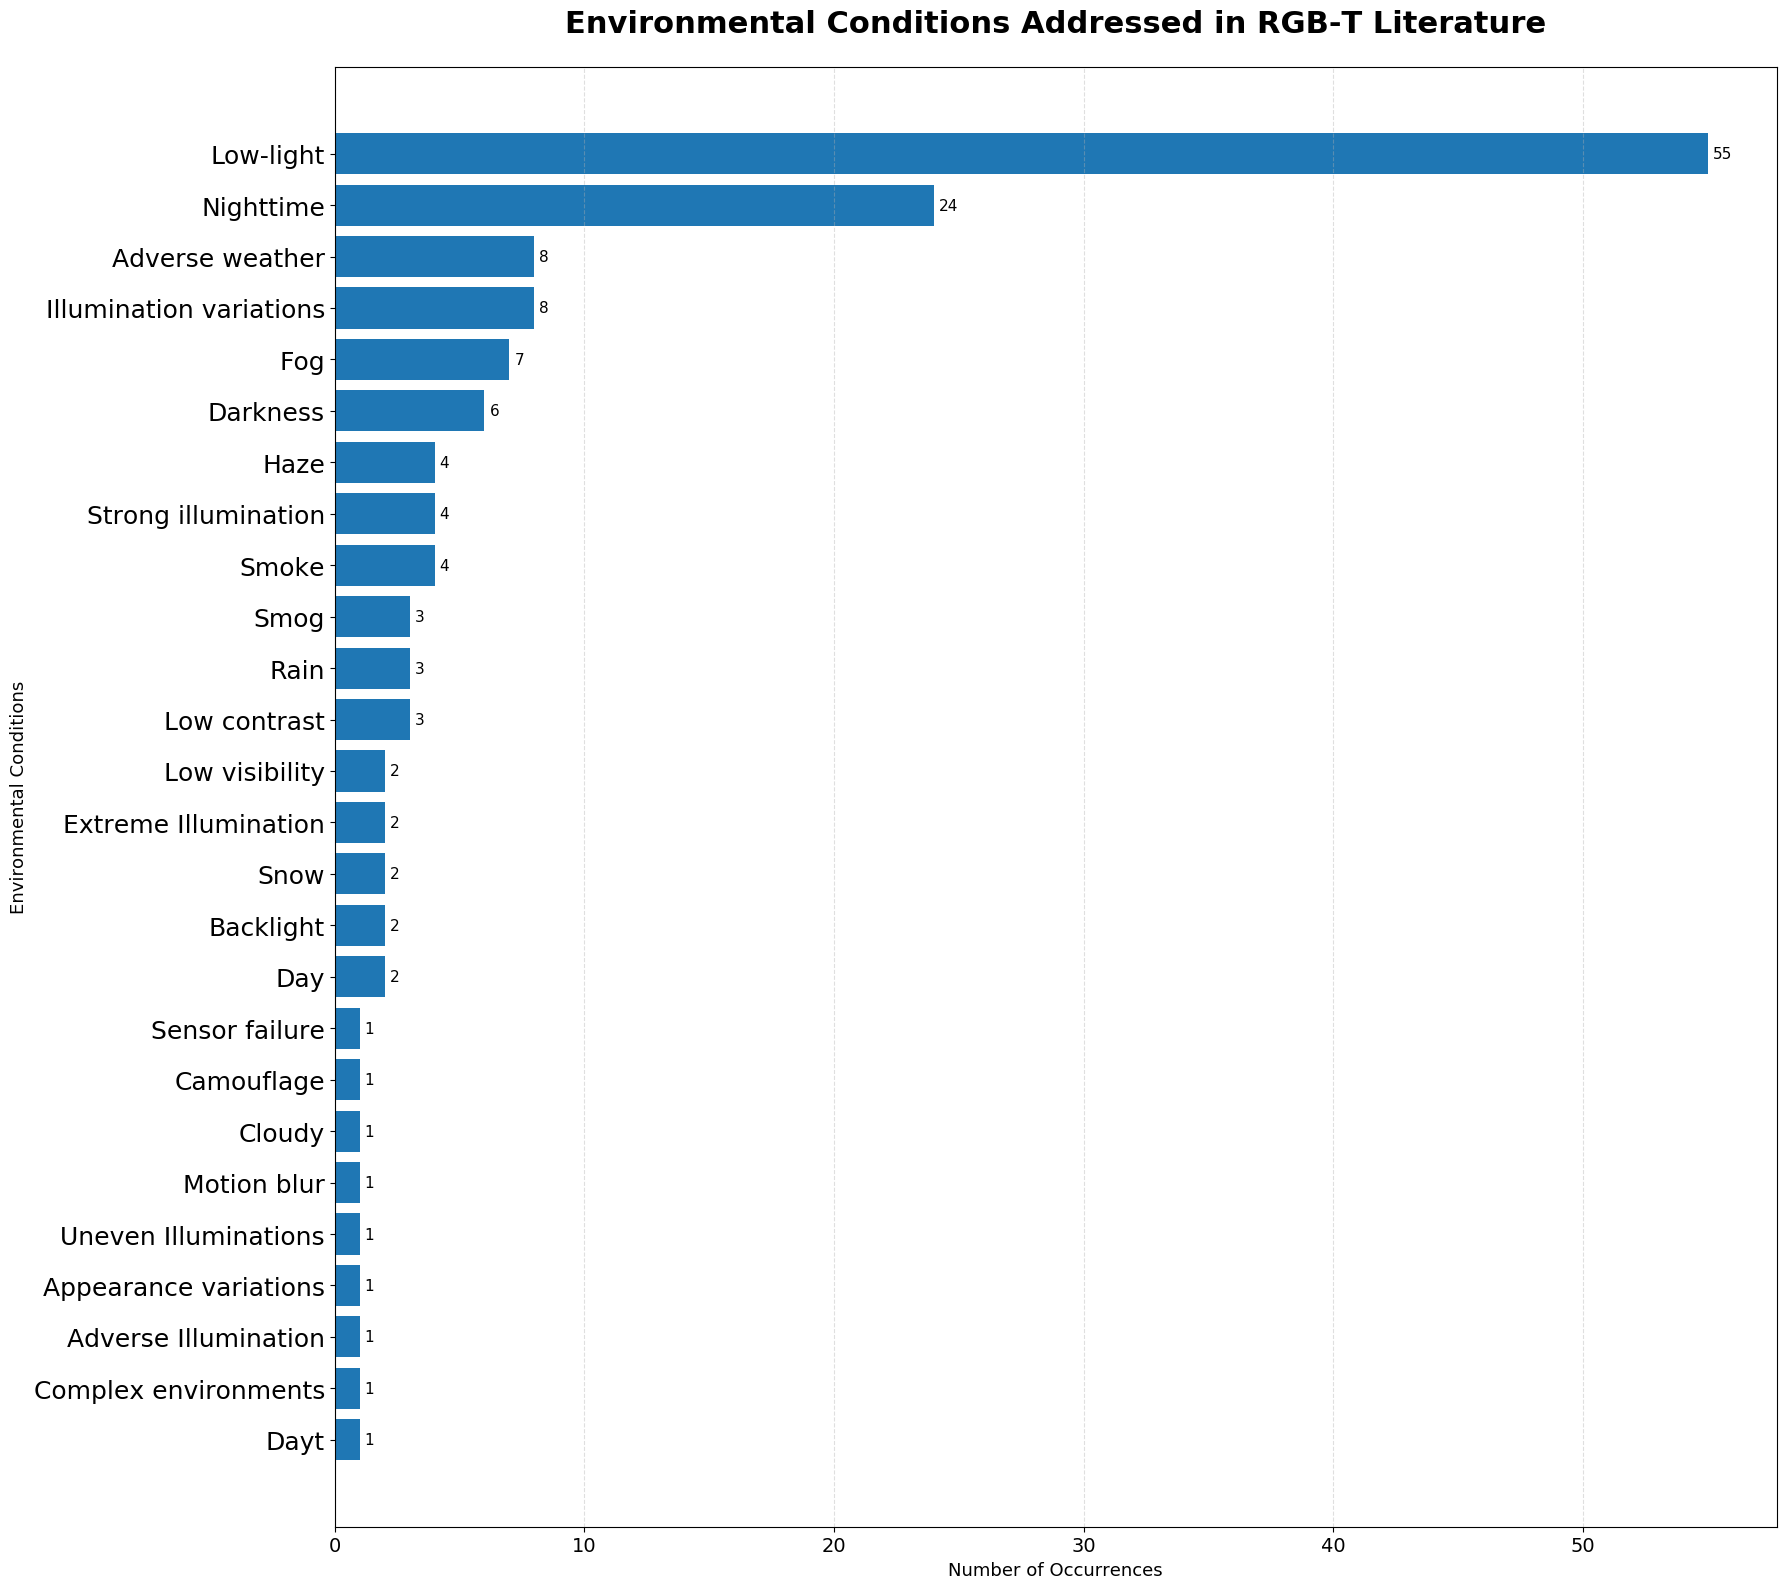

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1. Load Excel file
# =========================
file_path = "C:/Users/BasilisseNiombonana/Downloads/Data/Adverse_verified.xlsx"

df = pd.read_excel(file_path, engine="openpyxl")

# =========================
# 2. Column name
# =========================
column_name = "Adverse Condition Studied"

# =========================
# 3. FULL NORMALIZATION
# =========================
normalization = {

    # ================= LOW-LIGHT =================
    "low light": "Low-light",
    "low-light": "Low-light",
    "low-light conditions": "Low-light",
    "low illumination": "Low-light",
    "low-illumination": "Low-light",
    "poor illumination": "Low-light",
    "poor lighting": "Low-light",
    "poor light": "Low-light",
    "insufficient illumination": "Low-light",
    "insufficient lighting": "Low-light",
    "insufficient light": "Low-light",
    "dim light": "Low-light",
    "medium-light": "Low-light",

    # ================= NIGHTTIME =================
    "night": "Nighttime",
    "nighttime": "Nighttime",
    "night scene": "Nighttime",
    "night scenes": "Nighttime",
    "night illumination conditions": "Nighttime",
    "dark night": "Nighttime",
    "day-night": "Nighttime",
    "day/night": "Nighttime",
    "day-night conditions": "Nighttime",
    "day-night variations": "Nighttime",

    # ================= DARKNESS =================
    "dark": "Darkness",
    "darkness": "Darkness",
    "dark scenes": "Darkness",

    # ================= FOG =================
    "fog": "Fog",
    "foggy": "Fog",
    "foggy weather": "Fog",

    # ================= WEATHER =================
    "adverse weather": "Adverse weather",
    "extreme weather": "Adverse weather",
    "bad weather": "Adverse weather",
    "all-weather": "Adverse weather",

    # ================= ILLUMINATION =================
    "strong light": "Strong illumination",
    "strong illumination": "Strong illumination",
    "high-light": "Strong illumination",
    "illumination changes": "Illumination variations",
    "illumination variation": "Illumination variations",
    "illumination variations": "Illumination variations",
    "varying illumination": "Illumination variations",
    "varying lighting conditions": "Illumination variations",
    "lighting variations": "Illumination variations",
    "uneven illumination": "Illumination variations",
    "uneven lighting": "Illumination variations",

    # ================= OTHERS =================
    "haze": "Haze",
    "smoke": "Smoke",
    "smog": "Smog",
    "rain": "Rain",
    "snow": "Snow",
    "occlusion": "Occlusion",
    "camouflage": "Camouflage",
    "motion blur": "Motion blur",
    "low contrast": "Low contrast",
    "backlight": "Backlight",
    "complex environments": "Complex environments",
    "sensor failure": "Sensor failure",
    "appearance variations": "Appearance variations",
    "low visibility": "Low visibility"
}

# =========================
# 4. Extract conditions
# =========================
conditions = (
    df[column_name]
    .dropna()
    .astype(str)
    .str.replace("/", ",", regex=False)
    .str.replace(";", ",", regex=False)
    .str.split(",")
)

all_conditions = []

for row in conditions:

    for cond in row:

        cond = cond.strip().lower()

        cond = normalization.get(cond, cond.title())

        if cond not in ["", "Not Specified", "Not Explicitly Specified"]:
            all_conditions.append(cond)

# =========================
# 5. Count occurrences
# =========================
condition_counts = pd.Series(all_conditions).value_counts()

# Sort
condition_counts = condition_counts.sort_values(ascending=True)

# =========================
# 6. Plot
# =========================
plt.figure(figsize=(18, 16))

bars = plt.barh(
    condition_counts.index,
    condition_counts.values
)

# Add values
for i, value in enumerate(condition_counts.values):

    plt.text(
        value + 0.2,
        i,
        str(value),
        va='center',
        fontsize=11
    )

# Increase environmental condition names size
plt.yticks(fontsize=18)

# X-axis numbers
plt.xticks(fontsize=14)

# Title
plt.title(
    "Environmental Conditions Addressed in RGB-T Literature",
    fontsize=22,
    weight='bold',
    pad=25
)

# Labels
plt.xlabel(
    "Number of Occurrences",
    fontsize=13
)

plt.ylabel(
    "Environmental Conditions",
    fontsize=13
)

# Grid
plt.grid(
    axis='x',
    linestyle='--',
    alpha=0.4
)

plt.tight_layout()

# Save
plt.savefig(
    "C:/Users/BasilisseNiombonana/Downloads/Data/environmental_conditions_bar_chart.png",
    dpi=600,
    bbox_inches='tight'
)

plt.show()